In [1]:
# Import dependencies
import pandas as pd
from sklearn.cluster import KMeans
import pylab as pl
from math import sqrt
import yfinance as yf
import datetime as dt
from pandas_datareader import data as pdr
import tickers as ti

In [2]:
# Load stock data from Dow Jones Index
yf.pdr_override()
stocks = ti.tickers_dow()
start_date = dt.datetime(2014, 1, 1)
end_date = dt.datetime.now()

# Retrieve adjusted closing prices
data = pdr.get_data_yahoo(stocks, start=start_date, end=end_date)['Close']

# Calculate annual mean returns and variances
annual_returns = data.pct_change().mean() * 252
annual_variances = data.pct_change().std() * sqrt(252)

# Combine returns and variances into a DataFrame
ret_var = pd.concat([annual_returns, annual_variances], axis=1).dropna()
ret_var.columns = ["Returns", "Variance"]

/Users/Massimiliano/Documents/GitHub/DerivativeAnalytics/tickers.py:34: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html, header=0, attrs = {'id': 'constituents'})[0]


[*********************100%%**********************]  30 of 30 completed


In [3]:
print(ret_var)

       Returns  Variance
AAPL  0.263945  0.283282
AMGN  0.121857  0.247252
AXP   0.131484  0.304133
BA    0.120008  0.394180
CAT   0.167873  0.292513
CRM   0.225168  0.346577
CSCO  0.112751  0.248947
CVX   0.063247  0.295063
DIS   0.072244  0.273965
DOW   0.088894  0.378545
GS    0.116344  0.280954
HD    0.176727  0.240586
HON   0.106409  0.225751
IBM   0.032760  0.235567
INTC  0.105055  0.326904
JNJ   0.070073  0.179898
JPM   0.145102  0.268638
KO    0.054057  0.179597
MCD   0.129043  0.200598
MMM  -0.011534  0.234964
MRK   0.119826  0.214577
MSFT  0.276976  0.270064
NKE   0.138274  0.286654
PG    0.083209  0.183410
TRV   0.114133  0.231779
UNH   0.224380  0.253628
V     0.189950  0.246706
VZ   -0.002456  0.191707
WBA  -0.046833  0.301626
WMT   0.097142  0.207349


In [4]:
print(ret_var.values)

[[ 0.2639446   0.28328222]
 [ 0.12185694  0.24725176]
 [ 0.13148389  0.30413329]
 [ 0.12000773  0.3941803 ]
 [ 0.16787347  0.29251345]
 [ 0.22516806  0.34657677]
 [ 0.11275133  0.24894723]
 [ 0.06324743  0.29506281]
 [ 0.07224381  0.27396501]
 [ 0.08889415  0.37854471]
 [ 0.11634395  0.28095363]
 [ 0.17672726  0.24058581]
 [ 0.10640945  0.22575129]
 [ 0.03275976  0.23556656]
 [ 0.10505476  0.32690386]
 [ 0.07007345  0.17989789]
 [ 0.14510191  0.26863845]
 [ 0.05405658  0.17959718]
 [ 0.12904342  0.20059833]
 [-0.01153354  0.23496423]
 [ 0.11982622  0.21457701]
 [ 0.27697592  0.2700641 ]
 [ 0.13827388  0.2866536 ]
 [ 0.08320937  0.1834096 ]
 [ 0.1141331   0.23177889]
 [ 0.22437975  0.25362813]
 [ 0.18994951  0.24670587]
 [-0.0024564   0.19170691]
 [-0.04683264  0.30162597]
 [ 0.09714245  0.2073493 ]]


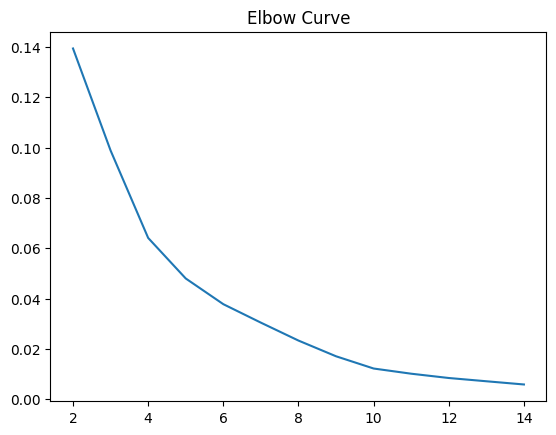

In [5]:
import warnings
warnings.filterwarnings("ignore")

# KMeans clustering
X = ret_var.values
sse = [KMeans(n_clusters=k).fit(X).inertia_ for k in range(2, 15)]

# Plotting the elbow curve to find optimal k
pl.plot(range(2, 15), sse)
pl.title("Elbow Curve")
pl.show()

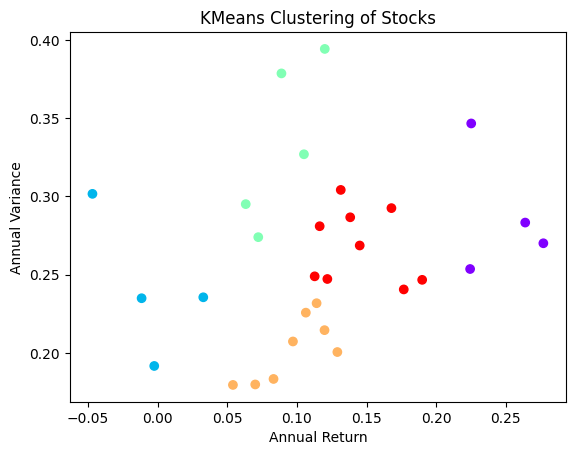

       Cluster
Stock         
AAPL         0
AMGN         4
AXP          4
BA           2
CAT          4
CRM          0
CSCO         4
CVX          2
DIS          2
DOW          2
GS           4
HD           4
HON          3
IBM          1
INTC         2
JNJ          3
JPM          4
KO           3
MCD          3
MMM          1
MRK          3
MSFT         0
NKE          4
PG           3
TRV          3
UNH          0
V            4
VZ           1
WBA          1
WMT          3


In [6]:
# Apply KMeans with chosen number of clusters
kmeans = KMeans(n_clusters=5).fit(X)

# Plotting the clustering result
pl.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="rainbow")
pl.title("KMeans Clustering of Stocks")
pl.xlabel("Annual Return")
pl.ylabel("Annual Variance")
pl.show()

# Creating a DataFrame with tickers and their cluster labels
df = pd.DataFrame({'Stock': ret_var.index, 'Cluster': kmeans.labels_})
df.set_index('Stock', inplace=True)

print(df)